# Resume Screening — DL Pipeline (Stage 1 + 2)

**Stage 1:** SBERT semantic matching — scores how well a CV matches a job description  
**Stage 2:** DistilBERT classifier — predicts which job category a CV belongs to  

No UI yet — focused purely on getting both models working correctly.

---

## 0. Install Dependencies

In [3]:
# Run this cell first — installs everything needed
# If you're on Google Colab, restart runtime after this cell

!pip install sentence-transformers transformers torch pdfplumber scikit-learn pandas numpy matplotlib seaborn datasets -q


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [4]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import torch

from pathlib import Path
from sentence_transformers import SentenceTransformer, util
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset

warnings.filterwarnings('ignore')

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cpu


---
## 2. Configuration
Edit this section to match your job requirements and file paths.

In [5]:
# ─── PATHS ───────────────────────────────────────────────────────────────────
CV_FOLDER = './cvs'          # Folder containing your PDF resumes
RESULTS_CSV = './results.csv'  # Output file path

# ─── JOB REQUIREMENTS ────────────────────────────────────────────────────────
# You can define multiple jobs here — system will match CVs to ALL of them
JOB_REQUIREMENTS = [
    {
        'title': 'Python Backend Developer',
        'description': """
            We are looking for an experienced Python backend developer.
            The candidate should have strong knowledge of Python, REST APIs,
            Django or FastAPI, PostgreSQL, and cloud platforms like AWS or GCP.
            Experience with Docker and CI/CD pipelines is a plus.
        """,
        'required_skills': ['python', 'django', 'fastapi', 'rest api', 'postgresql', 'sql'],
        'preferred_skills': ['docker', 'aws', 'gcp', 'redis', 'celery', 'git'],
        'min_experience_years': 2,
        'required_education': 'bachelor',  # bachelor / master / phd / any
    },
    {
        'title': 'Data Scientist',
        'description': """
            Seeking a data scientist with hands-on experience in machine learning,
            deep learning, and statistical modeling. Proficiency in Python, scikit-learn,
            TensorFlow or PyTorch required. Experience with NLP is a strong plus.
        """,
        'required_skills': ['python', 'machine learning', 'deep learning', 'scikit-learn', 'statistics'],
        'preferred_skills': ['tensorflow', 'pytorch', 'nlp', 'sql', 'tableau', 'spark'],
        'min_experience_years': 1,
        'required_education': 'bachelor',
    }
]

# ─── SCORING WEIGHTS ─────────────────────────────────────────────────────────
# Must sum to 1.0
WEIGHTS = {
    'sbert_similarity': 0.40,   # Stage 1 — semantic match with job description
    'required_skills':  0.30,   # How many required skills matched
    'experience':       0.15,   # Years of experience vs requirement
    'education':        0.15,   # Education level match
}

# ─── STAGE 2 CONFIG ──────────────────────────────────────────────────────────
# Job categories for the classifier (edit to match your domain)
JOB_CATEGORIES = [
    'Data Science', 'Web Developer', 'Backend Developer',
    'HR', 'Finance', 'Marketing', 'DevOps', 'Designer'
]

CLASSIFIER_EPOCHS = 3          # Keep low for first run (3 is enough)
CLASSIFIER_BATCH_SIZE = 8      # Reduce to 4 if you get out-of-memory errors
MAX_TOKEN_LENGTH = 256         # Max token length for DistilBERT input

print('Config loaded.')
print(f'Jobs defined: {[j["title"] for j in JOB_REQUIREMENTS]}')
print(f'Scoring weights sum: {sum(WEIGHTS.values())}')

Config loaded.
Jobs defined: ['Python Backend Developer', 'Data Scientist']
Scoring weights sum: 1.0


---
## 3. PDF Text Extraction

In [6]:
def extract_text_from_pdf(pdf_path: str) -> str:
    """
    Extracts all text from a PDF resume.
    Returns cleaned plain text string.
    """
    text = ''
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + '\n'
    except Exception as e:
        print(f'Error reading {pdf_path}: {e}')
        return ''
    
    # Basic cleanup
    text = re.sub(r'\s+', ' ', text)   # collapse whitespace
    text = text.strip()
    return text


def load_all_cvs(folder: str) -> list[dict]:
    """
    Loads all PDF files from the given folder.
    Returns list of dicts with filename and extracted text.
    """
    folder_path = Path(folder)
    if not folder_path.exists():
        print(f'Folder not found: {folder}')
        print('Creating demo CVs for testing...')
        return _create_demo_cvs()
    
    pdf_files = list(folder_path.glob('*.pdf'))
    if not pdf_files:
        print(f'No PDF files found in {folder}')
        print('Creating demo CVs for testing...')
        return _create_demo_cvs()
    
    cvs = []
    for pdf_path in pdf_files:
        text = extract_text_from_pdf(str(pdf_path))
        if text:
            cvs.append({'filename': pdf_path.name, 'text': text})
            print(f'Loaded: {pdf_path.name} ({len(text)} chars)')
    
    return cvs


def _create_demo_cvs() -> list[dict]:
    """
    Creates 5 sample CVs for testing when no real PDFs are available.
    Replace with your real PDFs when ready.
    """
    return [
        {
            'filename': 'alice_sharma.pdf',
            'text': """Alice Sharma | alice@email.com | Dhaka, Bangladesh
            Education: BSc Computer Science, BUET, 2021
            Experience: 3 years backend development at TechCorp BD
            Skills: Python, Django, FastAPI, PostgreSQL, REST API, Docker, Git, AWS
            Projects: Built microservices architecture handling 100k daily requests.
            Deployed CI/CD pipeline using GitHub Actions and AWS ECS."""
        },
        {
            'filename': 'bob_rahman.pdf',
            'text': """Bob Rahman | bob@email.com | Chittagong, Bangladesh
            Education: MSc Data Science, DU, 2022
            Experience: 2 years data analyst at Analytics BD, 1 year ML internship
            Skills: Python, Machine Learning, Deep Learning, scikit-learn, TensorFlow, PyTorch, NLP, SQL, Tableau
            Projects: Sentiment analysis model for Bengali text. Customer churn prediction with 91% accuracy."""
        },
        {
            'filename': 'carol_hasan.pdf',
            'text': """Carol Hasan | carol@email.com | Sylhet, Bangladesh
            Education: BSc Software Engineering, SUST, 2023
            Experience: 1 year junior developer
            Skills: JavaScript, React, Node.js, HTML, CSS, MongoDB
            Projects: Built an e-commerce website with React frontend and Node backend."""
        },
        {
            'filename': 'david_islam.pdf',
            'text': """David Islam | david@email.com | Dhaka, Bangladesh
            Education: BSc Computer Science, NSU, 2020
            Experience: 4 years Python developer, 2 years Django REST framework
            Skills: Python, Django, SQL, PostgreSQL, Redis, Celery, Git, Docker
            Projects: Developed SaaS billing system. Optimized DB queries reducing load time by 60%."""
        },
        {
            'filename': 'eva_chowdhury.pdf',
            'text': """Eva Chowdhury | eva@email.com | Rajshahi, Bangladesh
            Education: BSc Statistics, RU, 2021
            Experience: 1.5 years data science intern at StartupXYZ
            Skills: Python, scikit-learn, Pandas, NumPy, Matplotlib, Statistics, R
            Projects: Predictive model for sales forecasting. Exploratory data analysis dashboard."""
        }
    ]


# Load CVs
cvs = load_all_cvs(CV_FOLDER)
print(f'\nTotal CVs loaded: {len(cvs)}')

Folder not found: ./cvs
Creating demo CVs for testing...

Total CVs loaded: 5


---
## 4. CV Information Extraction (Rule-based)
Extracts structured fields from raw CV text before passing to models.

In [7]:
# Skills keyword bank — expand this as needed
SKILL_KEYWORDS = [
    # Programming languages
    'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'r', 'go', 'rust', 'kotlin', 'swift',
    # Web / backend
    'django', 'fastapi', 'flask', 'node.js', 'express', 'react', 'vue', 'angular', 'rest api', 'graphql',
    # Databases
    'postgresql', 'mysql', 'mongodb', 'redis', 'sqlite', 'sql', 'nosql', 'elasticsearch',
    # ML / DL
    'machine learning', 'deep learning', 'scikit-learn', 'tensorflow', 'pytorch', 'keras',
    'nlp', 'computer vision', 'transformers', 'bert', 'statistics',
    # DevOps / Cloud
    'docker', 'kubernetes', 'aws', 'gcp', 'azure', 'ci/cd', 'git', 'linux', 'celery',
    # Data
    'pandas', 'numpy', 'matplotlib', 'tableau', 'spark', 'hadoop', 'airflow',
]

EDUCATION_LEVELS = {
    'phd': 4, 'ph.d': 4, 'doctorate': 4,
    'master': 3, 'msc': 3, 'm.sc': 3, 'mba': 3, 'ms ': 3,
    'bachelor': 2, 'bsc': 2, 'b.sc': 2, 'btech': 2, 'b.tech': 2, 'beng': 2,
    'diploma': 1, 'hsc': 1, 'ssc': 0
}


def extract_skills(text: str) -> list[str]:
    text_lower = text.lower()
    return [skill for skill in SKILL_KEYWORDS if skill in text_lower]


def extract_experience_years(text: str) -> float:
    patterns = [
        r'(\d+\.?\d*)\+?\s*years?\s*(?:of\s*)?(?:experience|exp)',
        r'experience[:\s]+(\d+\.?\d*)\+?\s*years?',
        r'(\d+\.?\d*)\+?\s*years?\s*(?:backend|frontend|python|data|ml|software)',
    ]
    years = []
    for pattern in patterns:
        matches = re.findall(pattern, text.lower())
        years.extend([float(m) for m in matches])
    return max(years) if years else 0.0


def extract_education_level(text: str) -> tuple[str, int]:
    text_lower = text.lower()
    best_level = ('none', 0)
    for keyword, level in EDUCATION_LEVELS.items():
        if keyword in text_lower and level > best_level[1]:
            best_level = (keyword, level)
    return best_level


def extract_cv_info(cv: dict) -> dict:
    text = cv['text']
    skills = extract_skills(text)
    experience = extract_experience_years(text)
    edu_label, edu_level = extract_education_level(text)
    
    return {
        'filename': cv['filename'],
        'raw_text': text,
        'skills': skills,
        'experience_years': experience,
        'education_label': edu_label,
        'education_level': edu_level,
    }


# Extract info from all CVs
cv_profiles = [extract_cv_info(cv) for cv in cvs]

# Preview
for p in cv_profiles:
    print(f"\n{'='*50}")
    print(f"CV       : {p['filename']}")
    print(f"Skills   : {p['skills']}")
    print(f"Exp      : {p['experience_years']} years")
    print(f"Education: {p['education_label']} (level {p['education_level']})")


CV       : alice_sharma.pdf
Skills   : ['python', 'r', 'go', 'django', 'fastapi', 'rest api', 'postgresql', 'sql', 'docker', 'aws', 'ci/cd', 'git']
Exp      : 3.0 years
Education: bsc (level 2)

CV       : bob_rahman.pdf
Skills   : ['python', 'r', 'go', 'sql', 'machine learning', 'deep learning', 'scikit-learn', 'tensorflow', 'pytorch', 'nlp', 'tableau']
Exp      : 2.0 years
Education: msc (level 3)

CV       : carol_hasan.pdf
Skills   : ['java', 'javascript', 'r', 'go', 'node.js', 'react', 'mongodb']
Exp      : 1.0 years
Education: bsc (level 2)

CV       : david_islam.pdf
Skills   : ['python', 'r', 'go', 'django', 'postgresql', 'redis', 'sql', 'docker', 'git', 'celery']
Exp      : 4.0 years
Education: bsc (level 2)

CV       : eva_chowdhury.pdf
Skills   : ['python', 'r', 'scikit-learn', 'statistics', 'pandas', 'numpy', 'matplotlib']
Exp      : 1.5 years
Education: bsc (level 2)


---
## 5. Stage 1 — SBERT Semantic Matching
Loads `all-MiniLM-L6-v2` and computes cosine similarity between each CV and each job description.

In [8]:
print('Loading SBERT model...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
print(f'SBERT loaded on {device}')

Loading SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT loaded on cpu


In [9]:
def compute_sbert_similarity(cv_text: str, job_description: str) -> float:
    """
    Returns cosine similarity (0 to 1) between CV text and job description.
    Converted to percentage (0–100) for the final score.
    """
    embeddings = sbert_model.encode(
        [cv_text, job_description],
        convert_to_tensor=True,
        device=device
    )
    score = util.cos_sim(embeddings[0], embeddings[1]).item()
    # Normalize: cosine similarity can be slightly negative; clip to 0
    return max(0.0, score)


# Compute SBERT similarity for each CV × each job
print('Computing SBERT similarities...\n')
for profile in cv_profiles:
    profile['sbert_scores'] = {}
    for job in JOB_REQUIREMENTS:
        score = compute_sbert_similarity(profile['raw_text'], job['description'])
        profile['sbert_scores'][job['title']] = round(score * 100, 2)
        print(f"{profile['filename']:<30} → {job['title']:<30} SBERT: {score*100:.1f}%")

Computing SBERT similarities...

alice_sharma.pdf               → Python Backend Developer       SBERT: 61.5%
alice_sharma.pdf               → Data Scientist                 SBERT: 30.9%
bob_rahman.pdf                 → Python Backend Developer       SBERT: 38.8%
bob_rahman.pdf                 → Data Scientist                 SBERT: 49.6%
carol_hasan.pdf                → Python Backend Developer       SBERT: 45.2%
carol_hasan.pdf                → Data Scientist                 SBERT: 33.5%
david_islam.pdf                → Python Backend Developer       SBERT: 67.0%
david_islam.pdf                → Data Scientist                 SBERT: 42.1%
eva_chowdhury.pdf              → Python Backend Developer       SBERT: 43.0%
eva_chowdhury.pdf              → Data Scientist                 SBERT: 43.8%


---
## 6. Hybrid Scoring (SBERT + Rule-based)
Combines SBERT semantic score with structured matching for skills, experience, and education.

In [10]:
EDUCATION_REQUIRED_LEVELS = {
    'any': 0, 'diploma': 1, 'bachelor': 2, 'master': 3, 'phd': 4
}


def score_skills(cv_skills: list[str], job: dict) -> tuple[float, list, list]:
    cv_skills_lower = [s.lower() for s in cv_skills]
    required = job['required_skills']
    preferred = job.get('preferred_skills', [])

    matched_req = [s for s in required if s.lower() in cv_skills_lower]
    matched_pref = [s for s in preferred if s.lower() in cv_skills_lower]
    missing = [s for s in required if s.lower() not in cv_skills_lower]

    if not required:
        return 1.0, matched_req + matched_pref, missing

    # Required skills = 80% of skill score, preferred = 20%
    req_score = len(matched_req) / len(required)
    pref_score = (len(matched_pref) / len(preferred)) if preferred else 0
    skill_score = 0.8 * req_score + 0.2 * pref_score
    return skill_score, matched_req + matched_pref, missing


def score_experience(cv_years: float, min_years: float) -> float:
    if min_years == 0:
        return 1.0
    return min(cv_years / min_years, 1.0)  # caps at 1.0


def score_education(cv_edu_level: int, required_edu: str) -> float:
    required_level = EDUCATION_REQUIRED_LEVELS.get(required_edu.lower(), 0)
    if cv_edu_level >= required_level:
        return 1.0
    elif cv_edu_level == required_level - 1:
        return 0.5
    return 0.0


def compute_hybrid_score(profile: dict, job: dict) -> dict:
    sbert_raw = profile['sbert_scores'][job['title']] / 100  # back to 0–1
    skill_score, matched_skills, missing_skills = score_skills(profile['skills'], job)
    exp_score = score_experience(profile['experience_years'], job['min_experience_years'])
    edu_score = score_education(profile['education_level'], job['required_education'])

    final_score = (
        WEIGHTS['sbert_similarity'] * sbert_raw +
        WEIGHTS['required_skills']  * skill_score +
        WEIGHTS['experience']       * exp_score +
        WEIGHTS['education']        * edu_score
    )

    return {
        'filename': profile['filename'],
        'job_title': job['title'],
        'final_score_pct': round(final_score * 100, 2),
        'sbert_score_pct': round(sbert_raw * 100, 2),
        'skill_score_pct': round(skill_score * 100, 2),
        'exp_score_pct': round(exp_score * 100, 2),
        'edu_score_pct': round(edu_score * 100, 2),
        'matched_skills': matched_skills,
        'missing_skills': missing_skills,
        'experience_years': profile['experience_years'],
        'education': profile['education_label'],
    }


# Compute hybrid scores for all CV × job combinations
all_results = []
for profile in cv_profiles:
    for job in JOB_REQUIREMENTS:
        result = compute_hybrid_score(profile, job)
        all_results.append(result)

results_df = pd.DataFrame(all_results)
print('Hybrid scoring done.')
print(results_df[['filename', 'job_title', 'final_score_pct', 'sbert_score_pct', 'skill_score_pct']].to_string(index=False))

Hybrid scoring done.
         filename                job_title  final_score_pct  sbert_score_pct  skill_score_pct
 alice_sharma.pdf Python Backend Developer            81.62            61.54            90.00
 alice_sharma.pdf           Data Scientist            48.16            30.90            19.33
   bob_rahman.pdf Python Backend Developer            53.52            38.81            26.67
   bob_rahman.pdf           Data Scientist            74.02            49.55            80.67
  carol_hasan.pdf Python Backend Developer            40.59            45.23             0.00
  carol_hasan.pdf           Data Scientist            43.42            33.54             0.00
  david_islam.pdf Python Backend Developer            76.80            67.01            66.67
  david_islam.pdf           Data Scientist            52.66            42.14            19.33
eva_chowdhury.pdf Python Backend Developer            47.47            43.04            13.33
eva_chowdhury.pdf           Data Scient

---
## 7. Candidate Ranking

In [11]:
MEDALS = {1: '🥇', 2: '🥈', 3: '🥉'}

def generate_explanation(result: dict) -> str:
    lines = []
    if result['sbert_score_pct'] >= 70:
        lines.append('Strong semantic match with job description.')
    elif result['sbert_score_pct'] >= 50:
        lines.append('Moderate semantic alignment with job description.')
    else:
        lines.append('Low semantic similarity with job description.')

    if result['matched_skills']:
        lines.append(f"Matched skills: {', '.join(result['matched_skills'][:5])}.")
    if result['missing_skills']:
        lines.append(f"Missing skills: {', '.join(result['missing_skills'][:5])}.")

    if result['exp_score_pct'] == 100:
        lines.append(f"Meets experience requirement ({result['experience_years']} yrs).")
    else:
        lines.append(f"Below required experience ({result['experience_years']} yrs found).")

    return ' | '.join(lines)


def generate_suggestion(result: dict) -> str:
    suggestions = []
    if result['missing_skills']:
        suggestions.append(f"Develop: {', '.join(result['missing_skills'][:3])}.")
    if result['exp_score_pct'] < 100:
        suggestions.append('Gain more relevant experience.')
    if result['sbert_score_pct'] < 60:
        suggestions.append('Tailor CV language closer to the job description.')
    return ' '.join(suggestions) if suggestions else 'Strong candidate — no major gaps.'


def rank_candidates(df: pd.DataFrame, job_title: str) -> pd.DataFrame:
    job_df = df[df['job_title'] == job_title].copy()
    job_df = job_df.sort_values('final_score_pct', ascending=False).reset_index(drop=True)
    job_df['rank'] = job_df.index + 1
    job_df['medal'] = job_df['rank'].map(lambda r: MEDALS.get(r, f'#{r}'))
    job_df['explanation'] = job_df.apply(generate_explanation, axis=1)
    job_df['suggestion'] = job_df.apply(generate_suggestion, axis=1)
    return job_df


# Print rankings for each job
ranked_results = []
for job in JOB_REQUIREMENTS:
    ranked = rank_candidates(results_df, job['title'])
    ranked_results.append(ranked)

    print(f"\n{'='*60}")
    print(f"  RANKING: {job['title']}")
    print(f"{'='*60}")
    for _, row in ranked.iterrows():
        print(f"  {row['medal']}  {row['filename']:<28} Score: {row['final_score_pct']}%")
        print(f"       SBERT:{row['sbert_score_pct']}%  Skills:{row['skill_score_pct']}%  Exp:{row['exp_score_pct']}%  Edu:{row['edu_score_pct']}%")
        print(f"       {row['explanation']}")
        print(f"       Suggestion: {row['suggestion']}")
        print()


  RANKING: Python Backend Developer
  🥇  alice_sharma.pdf             Score: 81.62%
       SBERT:61.54%  Skills:90.0%  Exp:100.0%  Edu:100.0%
       Moderate semantic alignment with job description. | Matched skills: python, django, fastapi, rest api, postgresql. | Meets experience requirement (3.0 yrs).
       Suggestion: Strong candidate — no major gaps.

  🥈  david_islam.pdf              Score: 76.8%
       SBERT:67.01%  Skills:66.67%  Exp:100.0%  Edu:100.0%
       Moderate semantic alignment with job description. | Matched skills: python, django, postgresql, sql, docker. | Missing skills: fastapi, rest api. | Meets experience requirement (4.0 yrs).
       Suggestion: Develop: fastapi, rest api.

  🥉  bob_rahman.pdf               Score: 53.52%
       SBERT:38.81%  Skills:26.67%  Exp:100.0%  Edu:100.0%
       Low semantic similarity with job description. | Matched skills: python, sql. | Missing skills: django, fastapi, rest api, postgresql. | Meets experience requirement (2.0 yrs).


---
## 8. Score Visualization

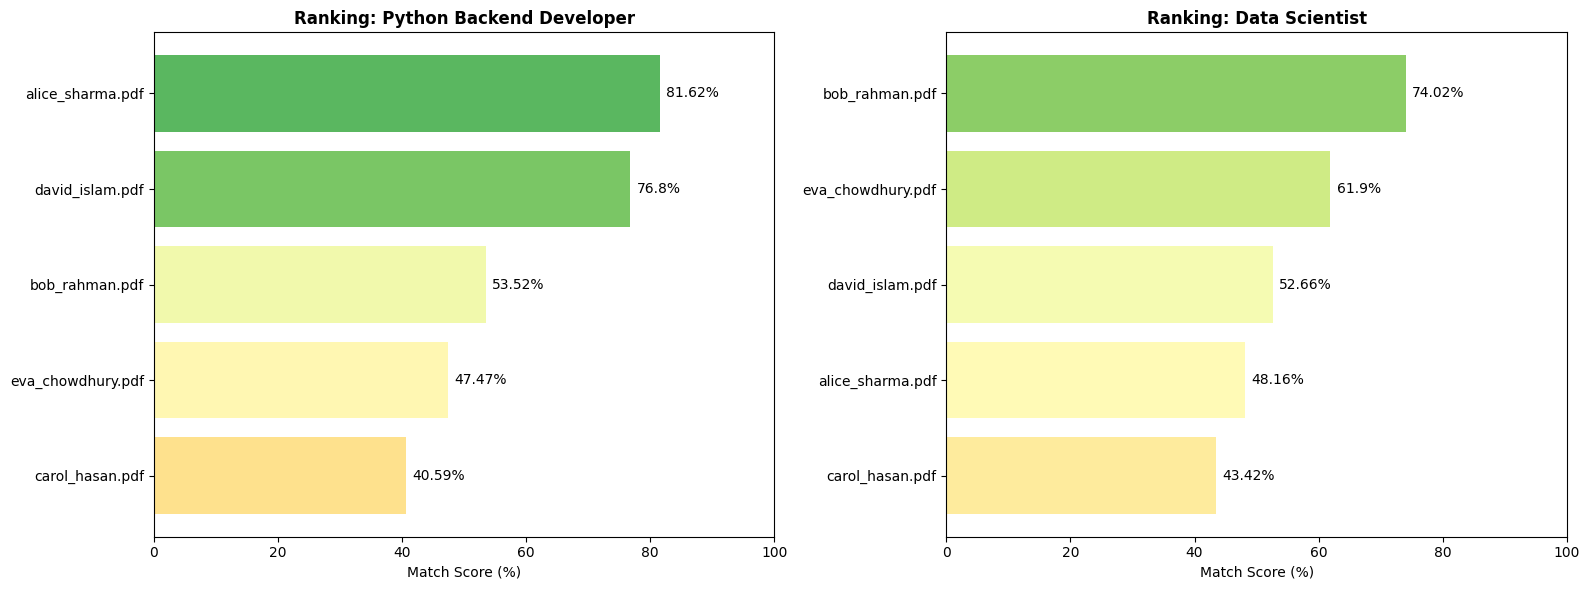

Chart saved as ranking_chart.png


In [12]:
fig, axes = plt.subplots(1, len(JOB_REQUIREMENTS), figsize=(8 * len(JOB_REQUIREMENTS), 6))
if len(JOB_REQUIREMENTS) == 1:
    axes = [axes]

colors = plt.cm.RdYlGn([s / 100 for s in results_df['final_score_pct']])

for ax, job, ranked in zip(axes, JOB_REQUIREMENTS, ranked_results):
    bars = ax.barh(
        ranked['filename'],
        ranked['final_score_pct'],
        color=plt.cm.RdYlGn(ranked['final_score_pct'] / 100)
    )
    ax.set_xlim(0, 100)
    ax.set_xlabel('Match Score (%)')
    ax.set_title(f'Ranking: {job["title"]}', fontweight='bold')
    ax.invert_yaxis()
    for bar, score in zip(bars, ranked['final_score_pct']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'{score}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('./ranking_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as ranking_chart.png')

---
## 9. Stage 2 — DistilBERT Job Category Classifier

This model learns to predict which job category a resume belongs to.  
We fine-tune `distilbert-base-uncased` on a small labeled dataset.

**Note:** If you have no labeled dataset yet, the cell below creates synthetic training data  
so you can see the full pipeline run. Replace with real data for better accuracy.

In [13]:
import pandas as pd

df = pd.read_csv('./UpdatedResumeDataSet.csv')
df = df.dropna()
df.columns = df.columns.str.strip()

print(f'Loaded: {len(df)} rows')
print(f'Categories: {df["Category"].nunique()}')
print(df['Category'].value_counts())

TRAINING_DATA = list(zip(df['Resume'].tolist(), df['Category'].tolist()))
print(f'Training samples ready: {len(TRAINING_DATA)}')

Loaded: 962 rows
Categories: 25
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64
Training samples ready: 962


In [14]:
# ─── LABEL ENCODING ──────────────────────────────────────────────────────────
texts  = [d[0] for d in TRAINING_DATA]
labels = [d[1] for d in TRAINING_DATA]

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_labels = len(label_encoder.classes_)

print(f'Classes ({num_labels}): {list(label_encoder.classes_)}')

# Train / val split
X_train, X_val, y_train, y_val = train_test_split(
    texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
)
print(f'Train: {len(X_train)} | Val: {len(X_val)}')

Classes (25): [np.str_('Advocate'), np.str_('Arts'), np.str_('Automation Testing'), np.str_('Blockchain'), np.str_('Business Analyst'), np.str_('Civil Engineer'), np.str_('Data Science'), np.str_('Database'), np.str_('DevOps Engineer'), np.str_('DotNet Developer'), np.str_('ETL Developer'), np.str_('Electrical Engineering'), np.str_('HR'), np.str_('Hadoop'), np.str_('Health and fitness'), np.str_('Java Developer'), np.str_('Mechanical Engineer'), np.str_('Network Security Engineer'), np.str_('Operations Manager'), np.str_('PMO'), np.str_('Python Developer'), np.str_('SAP Developer'), np.str_('Sales'), np.str_('Testing'), np.str_('Web Designing')]
Train: 769 | Val: 193


In [15]:
# ─── TOKENIZER & DATASET ─────────────────────────────────────────────────────
print('Loading DistilBERT tokenizer...')
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')


class ResumeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_TOKEN_LENGTH):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }


train_dataset = ResumeDataset(X_train, y_train, tokenizer)
val_dataset   = ResumeDataset(X_val,   y_val,   tokenizer)
print(f'Datasets created — Train: {len(train_dataset)} | Val: {len(val_dataset)}')

Loading DistilBERT tokenizer...
Datasets created — Train: 769 | Val: 193


In [16]:
# ─── MODEL & TRAINING ────────────────────────────────────────────────────────
print('Loading DistilBERT model for classification...')
classifier_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir='./distilbert_classifier',
    num_train_epochs=CLASSIFIER_EPOCHS,
    per_device_train_batch_size=CLASSIFIER_BATCH_SIZE,
    per_device_eval_batch_size=CLASSIFIER_BATCH_SIZE,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=5,
    warmup_steps=5,
    weight_decay=0.01,
    report_to='none',   # set to 'wandb' if you want experiment tracking
)

trainer = Trainer(
    model=classifier_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print(f'Training DistilBERT for {CLASSIFIER_EPOCHS} epochs...')
trainer.train()
print('Training complete.')

Loading DistilBERT model for classification...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training DistilBERT for 3 epochs...


Epoch,Training Loss,Validation Loss
1,2.005326,1.715050
2,0.673251,0.579173
3,0.385618,0.342015


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.


In [17]:
# ─── EVALUATION ──────────────────────────────────────────────────────────────
predictions_output = trainer.predict(val_dataset)
predicted_labels = np.argmax(predictions_output.predictions, axis=1)
true_labels = y_val

print('Classification Report:')
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=label_encoder.classes_,
    zero_division=0
))

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       1.00  

In [18]:
# ─── PREDICT CATEGORY FOR EACH UPLOADED CV ───────────────────────────────────
def predict_category(text: str) -> tuple[str, float]:
    """
    Predicts the job category for a given resume text.
    Returns (predicted_label, confidence_percentage)
    """
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=MAX_TOKEN_LENGTH
    ).to(device)

    classifier_model.to(device)
    classifier_model.eval()

    with torch.no_grad():
        outputs = classifier_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    predicted_idx = int(np.argmax(probs))
    confidence = float(probs[predicted_idx]) * 100
    label = label_encoder.inverse_transform([predicted_idx])[0]
    return label, round(confidence, 2)


print('\nCV Category Predictions:')
print(f"{'CV':<30} {'Predicted Category':<22} {'Confidence'}")
print('-' * 60)
for profile in cv_profiles:
    category, confidence = predict_category(profile['raw_text'])
    profile['predicted_category'] = category
    profile['category_confidence'] = confidence
    print(f"{profile['filename']:<30} {category:<22} {confidence}%")


CV Category Predictions:
CV                             Predicted Category     Confidence
------------------------------------------------------------
alice_sharma.pdf               Java Developer         27.63%
bob_rahman.pdf                 Data Science           66.46%
carol_hasan.pdf                Java Developer         52.25%
david_islam.pdf                Python Developer       28.26%
eva_chowdhury.pdf              Data Science           43.02%


In [21]:
# ─── ML MODEL: TF-IDF + Logistic Regression ──────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

print('Training ML Model: TF-IDF + Logistic Regression...')

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

# Predictions
lr_preds = lr_model.predict(X_val_tfidf)

# Results
lr_accuracy = accuracy_score(y_val, lr_preds)
print(f'\nML Model Accuracy: {round(lr_accuracy*100, 2)}%')
print('\nClassification Report:')
print(classification_report(
    y_val, lr_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

Training ML Model: TF-IDF + Logistic Regression...

ML Model Accuracy: 99.48%

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR 

In [22]:
# ─── ML MODEL 2: Random Forest ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

print('Training ML Model 2: Random Forest...')

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

rf_preds    = rf_model.predict(X_val_tfidf)
rf_accuracy = accuracy_score(y_val, rf_preds)

print(f'\nRandom Forest Accuracy: {round(rf_accuracy*100, 2)}%')
print('\nClassification Report:')
print(classification_report(
    y_val, rf_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

Training ML Model 2: Random Forest...

Random Forest Accuracy: 99.48%

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.

---
## 10. Final Combined Report

In [19]:
# Add category predictions to results dataframe
category_map = {
    p['filename']: (p['predicted_category'], p['category_confidence'])
    for p in cv_profiles
}
results_df['predicted_category']    = results_df['filename'].map(lambda f: category_map[f][0])
results_df['category_confidence_pct'] = results_df['filename'].map(lambda f: category_map[f][1])

# Build final ranked report for each job
final_report_frames = []
for job, ranked in zip(JOB_REQUIREMENTS, ranked_results):
    ranked['predicted_category']     = ranked['filename'].map(lambda f: category_map[f][0])
    ranked['category_confidence_pct'] = ranked['filename'].map(lambda f: category_map[f][1])
    final_report_frames.append(ranked)

final_report = pd.concat(final_report_frames, ignore_index=True)

# Save to CSV
cols_to_save = [
    'rank', 'medal', 'filename', 'job_title',
    'final_score_pct', 'sbert_score_pct', 'skill_score_pct', 'exp_score_pct', 'edu_score_pct',
    'matched_skills', 'missing_skills', 'experience_years', 'education',
    'predicted_category', 'category_confidence_pct',
    'explanation', 'suggestion'
]
final_report[cols_to_save].to_csv(RESULTS_CSV, index=False)
print(f'Final report saved to {RESULTS_CSV}')

# Display summary
display(final_report[['rank', 'medal', 'filename', 'job_title', 'final_score_pct',
                       'predicted_category', 'matched_skills', 'missing_skills']]
        .sort_values(['job_title', 'rank']))

Final report saved to ./results.csv


,rank,medal,filename,job_title,final_score_pct,predicted_category,matched_skills,missing_skills
5,1,🥇,bob_rahman.pdf,Data Scientist,74.02,Data Science,"[python, machine learning, deep learning, scik...",[statistics]
6,2,🥈,eva_chowdhury.pdf,Data Scientist,61.90,Data Science,"[python, scikit-learn, statistics]","[machine learning, deep learning]"
7,3,🥉,david_islam.pdf,Data Scientist,52.66,Python Developer,"[python, sql]","[machine learning, deep learning, scikit-learn..."
8,4,#4,alice_sharma.pdf,Data Scientist,48.16,Java Developer,"[python, sql]","[machine learning, deep learning, scikit-learn..."
9,5,#5,carol_hasan.pdf,Data Scientist,43.42,Java Developer,[],"[python, machine learning, deep learning, scik..."
0,1,🥇,alice_sharma.pdf,Python Backend Developer,81.62,Java Developer,"[python, django, fastapi, rest api, postgresql...",[]
1,2,🥈,david_islam.pdf,Python Backend Developer,76.80,Python Developer,"[python, django, postgresql, sql, docker, redi...","[fastapi, rest api]"
2,3,🥉,bob_rahman.pdf,Python Backend Developer,53.52,Data Science,"[python, sql]","[django, fastapi, rest api, postgresql]"
3,4,#4,eva_chowdhury.pdf,Python Backend Developer,47.47,Data Science,[python],"[django, fastapi, rest api, postgresql, sql]"
4,5,#5,carol_hasan.pdf,Python Backend Developer,40.59,Java Developer,[],"[python, django, fastapi, rest api, postgresql..."


---
## 11. Save Models (Optional)
Save both models so you don't have to retrain next time.

In [20]:
# Save DistilBERT classifier
classifier_model.save_pretrained('./saved_distilbert_classifier')
tokenizer.save_pretrained('./saved_distilbert_classifier')

# Save label encoder classes
import json
with open('./saved_distilbert_classifier/label_classes.json', 'w') as f:
    json.dump(list(label_encoder.classes_), f)

print('DistilBERT classifier saved to ./saved_distilbert_classifier/')
print('SBERT (all-MiniLM-L6-v2) is auto-cached by HuggingFace — no need to save manually.')
print('\nTo reload next time:')
print('  sbert_model = SentenceTransformer("all-MiniLM-L6-v2")')
print('  classifier_model = DistilBertForSequenceClassification.from_pretrained("./saved_distilbert_classifier")')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT classifier saved to ./saved_distilbert_classifier/
SBERT (all-MiniLM-L6-v2) is auto-cached by HuggingFace — no need to save manually.

To reload next time:
  sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
  classifier_model = DistilBertForSequenceClassification.from_pretrained("./saved_distilbert_classifier")


SBERT Average Similarity Score: 45.55%


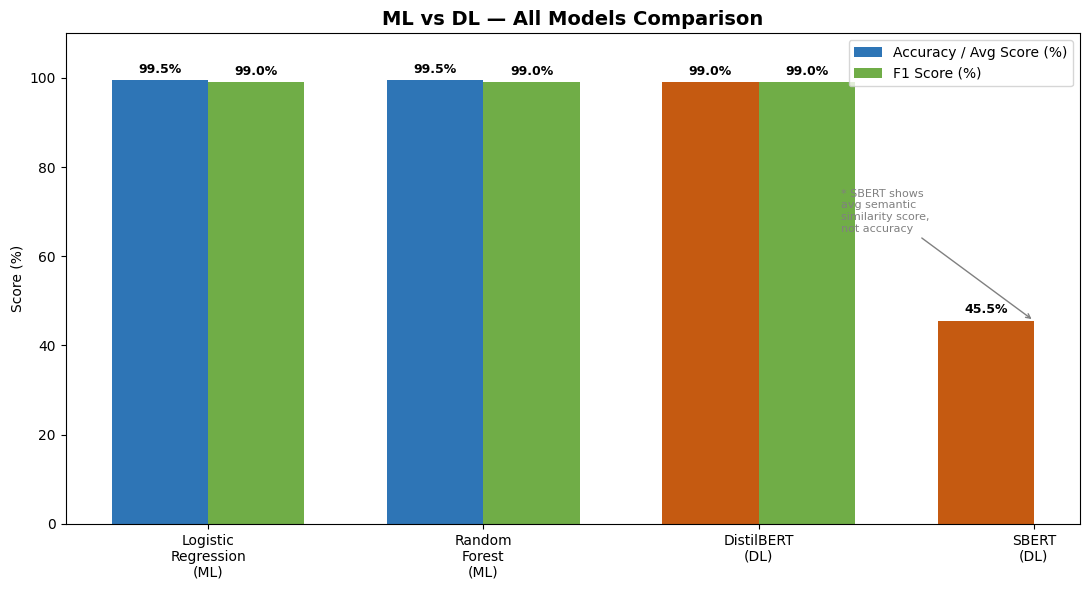

Chart saved!


In [24]:
# ─── ALL MODELS COMPARISON CHART ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# SBERT average similarity score from earlier results
sbert_avg = round(results_df['sbert_score_pct'].mean(), 2)
print(f'SBERT Average Similarity Score: {sbert_avg}%')

models     = ['Logistic\nRegression\n(ML)', 'Random\nForest\n(ML)', 'DistilBERT\n(DL)', 'SBERT\n(DL)']
accuracies = [99.48, 99.48, 99.0, sbert_avg]
f1_scores  = [99.0,  99.0,  99.0, None]
colors_acc = ['#2E75B6', '#2E75B6', '#C55A11', '#C55A11']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy / Avg Score (%)', color=colors_acc)

f1_vals = [99.0, 99.0, 99.0]
bars2 = ax.bar(x[:3] + width/2, f1_vals, width, label='F1 Score (%)', color='#70AD47')

ax.set_ylim(0, 110)
ax.set_ylabel('Score (%)')
ax.set_title('ML vs DL — All Models Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Annotation for SBERT
ax.annotate('* SBERT shows\navg semantic\nsimilarity score,\nnot accuracy',
            xy=(3, sbert_avg), xytext=(2.3, sbert_avg + 20),
            fontsize=8, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('./ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

---
## Next Steps

Once both models work correctly:

1. **Add real CVs** — put your PDF files in the `./cvs/` folder and rerun
2. **Add real training data** — replace `TRAINING_DATA` in Section 9 with real labeled resumes (more data = better accuracy)
3. **Add a UI** — wrap this notebook in Streamlit or Gradio for HR upload interface
4. **Stage 3 (optional)** — add Siamese BERT to replace the rule-based skill scoring with learned similarity

---